In [23]:
import torch
import torch.nn as nn

In [24]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter('runs/vae_gan')

In [25]:
device = torch.device("cpu")
# for nvidia gpu ( cuda backend )
if (torch.cuda.is_available()):
    device = torch.device("cuda")
  # mps for apple M GPU ( metal backend )
elif (torch.backends.mps.is_available()):
    device = torch.device("mps")

print("Using device:", device)

Using device: mps


In [26]:
lr_g = 1e-3
lr_d = 1e-4
batch_size = 256
epochs = 50
alpha = 0.5
beta = 0.5

In [27]:
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

dataset_path = '../data'


mnist_transform = transforms.Compose([
    transforms.ToTensor(),
])

kwargs = {'num_workers': 1, 'pin_memory': True}

train_dataset = MNIST(
    dataset_path, transform=mnist_transform, train=True, download=True)
test_dataset = MNIST(dataset_path, transform=mnist_transform,
                     train=False, download=True)

train_loader = DataLoader(dataset=train_dataset,
                          batch_size=batch_size, shuffle=True, **kwargs)
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=batch_size, shuffle=False, **kwargs)

In [28]:
import sys
sys.path.append('../')
from model import VAE , Discriminator

vae = VAE(encoder=nn.Sequential(
    nn.Linear(784, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
),
    decoder=nn.Sequential(
        nn.Linear(128, 256),
        nn.ReLU(),
        nn.Linear(256, 512),
        nn.ReLU(),
        nn.Linear(512, 784),
        nn.Sigmoid()
),
    mean=nn.Linear(256, 128),
    var=nn.Linear(256, 128)).to(device)
dis = Discriminator(
    nn.Sequential(
        nn.Linear(784, 512),
        nn.ReLU(),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Linear(256, 1),
        nn.Sigmoid()
    )
).to(device)

vae_opt = torch.optim.Adam(vae.parameters(), lr=lr_g)
dis_opt = torch.optim.Adam(dis.parameters(), lr=lr_d)

VAE model initialized
Discriminator model initialized


In [29]:
print("Start training VAE GAN...")
vae.train()
dis.train()
BCE = nn.BCELoss(reduction='sum').to(device)
MSE = nn.MSELoss(reduction='sum').to(device)
for epoch in range(epochs):
    overall_gen_loss = 0
    overall_dis_loss = 0
    overall_rec_loss = 0
    overall_kl_loss = 0
    overall_dis_loss_fake = 0
    overall_dis_loss_real = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        batch_size = x.size(0)
        x = x.view(batch_size, 784)
        x = x.to(device)
        real_label = torch.ones(batch_size, 1).to(device)
        fake_label = torch.zeros(batch_size, 1).to(device)

        # Train Discriminator
        _, mean, log_var,_,x_hat = vae(x)
        dis_real = dis(x)
        dis_fake = dis(x_hat.detach())
        dis_loss_real = BCE(dis_real, real_label)
        dis_loss_fake = BCE(dis_fake, fake_label)
        dis_loss = dis_loss_real + dis_loss_fake
        overall_dis_loss += dis_loss.item()
        overall_dis_loss_real += dis_loss_real.item()
        overall_dis_loss_fake += dis_loss_fake.item()
        dis_opt.zero_grad()
        dis_loss.backward()
        dis_opt.step()

        # Train Generator

        dis_fake = dis(x_hat)
        dis_loss_fake = BCE(dis_fake, real_label)
        rec_loss = MSE(x_hat, x)
        overall_rec_loss += rec_loss.item()
        kl = -beta * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
        overall_kl_loss += kl.item()
        vae_loss = rec_loss + kl + alpha*dis_loss_fake
        overall_gen_loss += vae_loss.item()
        vae_opt.zero_grad()
        vae_loss.backward()
        vae_opt.step()

    writer.add_scalar('Generator Loss', overall_gen_loss /
                      ((batch_idx)*batch_size), epoch+1)
    writer.add_scalar('Discriminator Loss', overall_dis_loss /
                      ((batch_idx)*batch_size), epoch+1)
    writer.add_scalar('Reconstruction Loss', overall_rec_loss /
                      ((batch_idx)*batch_size), epoch+1)
    writer.add_scalar('KL Loss', overall_kl_loss /
                      ((batch_idx)*batch_size), epoch+1)
    writer.add_scalar('Discriminator Loss Real', overall_dis_loss_real /
                      ((batch_idx)*batch_size), epoch+1)
    writer.add_scalar('Discriminator Loss Fake', overall_dis_loss_fake /
                      ((batch_idx)*batch_size), epoch+1)
    print("Epoch: {}/{} Generator Loss: {} Discriminator Loss:{}".format(epoch,epochs,overall_gen_loss /(batch_idx*batch_size),overall_dis_loss/(batch_idx*batch_size)))   

Start training VAE GAN...
Epoch: 0/50 Generator Loss: 146.66309467543903 Discriminator Loss:1.7845230591602814
Epoch: 1/50 Generator Loss: 127.51811013941752 Discriminator Loss:0.6277981599171957
Epoch: 2/50 Generator Loss: 114.23991796162053 Discriminator Loss:0.5972238899635793
Epoch: 3/50 Generator Loss: 103.5523257241969 Discriminator Loss:0.5445017823975989
Epoch: 4/50 Generator Loss: 98.13766781624905 Discriminator Loss:0.5467223224476871
Epoch: 5/50 Generator Loss: 95.10221610653434 Discriminator Loss:0.5890070847806088
Epoch: 6/50 Generator Loss: 93.14594142729061 Discriminator Loss:0.6564033543452238
Epoch: 7/50 Generator Loss: 91.15162863011373 Discriminator Loss:0.7560205333932513
Epoch: 8/50 Generator Loss: 90.06647262138519 Discriminator Loss:0.8337729498531744
Epoch: 9/50 Generator Loss: 89.36779451506091 Discriminator Loss:0.8778007665590682
Epoch: 10/50 Generator Loss: 88.85990380833292 Discriminator Loss:0.9551336816233448
Epoch: 11/50 Generator Loss: 88.10444500915006

In [30]:
vae.eval()

with torch.no_grad():
    for batch_idx, (x, _) in enumerate(test_loader):
        batch_size = x.size(0)
        x = x.view(batch_size, 784)
        x = x.to(device)
        _, _, _, _, x_hat = vae(x)
        break

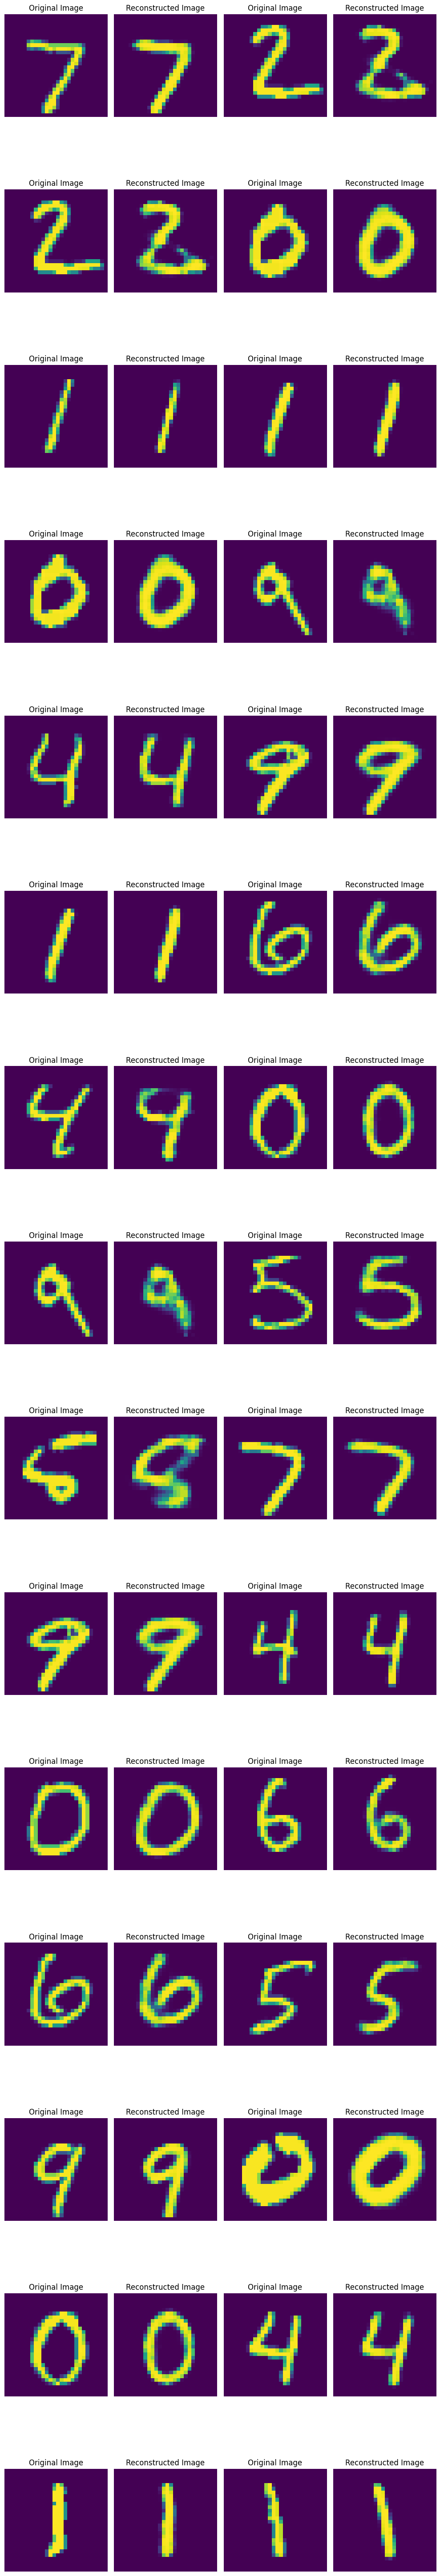

In [31]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=15, ncols=4, figsize=(10, 60))

for i in range(15):

    original_image = x[i].view(28, 28).cpu().numpy()
    reconstructed_image = x_hat[i].view(28, 28).cpu().numpy()

    axes[i, 0].imshow(original_image)
    axes[i, 0].set_title('Original Image')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(reconstructed_image)
    axes[i, 1].set_title('Reconstructed Image')
    axes[i, 1].axis('off')
    j = i*2+1
    original_image = x[j].view(28, 28).cpu().numpy()
    reconstructed_image = x_hat[j].view(28, 28).cpu().numpy()

    # Add your own images or modify as per your requirement
    axes[i, 2].imshow(original_image)
    axes[i, 2].set_title('Original Image')
    axes[i, 2].axis('off')

    axes[i, 3].imshow(reconstructed_image)
    axes[i, 3].set_title('Reconstructed Image')
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()